# Hackathon 2 — ¿La escala cambia la historia?
## PCA con Palmer Penguins

**Integrantes:** Roberth Chachalo · Jaime Astudillo  
**Equipo:** Chachalo–Astudillo

### Pregunta central

¿Cómo cambian las componentes principales y las conclusiones cuando las variables se usan en sus unidades originales o se estandarizan antes de aplicar PCA?

### Restricciones

- Trabajen con las cuatro mediciones numéricas indicadas.
- Calculen PCA con `numpy.linalg.svd`; no usen `sklearn.decomposition.PCA`.
- Escriban respuestas breves, pero deben citar resultados numéricos o elementos del gráfico.
- Ejecuten las celdas en orden. Al finalizar, reinicien el kernel y ejecuten todo.

## Plan sugerido — 90 minutos

| Etapa | Tiempo |
|---|---:|
| Auditoría y limpieza | 10 min |
| Predicción y preparación de matrices | 10 min |
| PCA con SVD y comparación de escalas | 25 min |
| Varianza explicada y cargas | 15 min |
| Visualización | 15 min |
| Reconstrucción, decisión y verificación | 15 min |

## 0. Preparación

Esta celda define las rutas y las cuatro variables. No modifiquen sus nombres.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("data/penguins.csv")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

FEATURES = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]
LABEL = "species"

## Tarea 1. Auditar y limpiar los datos

1. Carguen el CSV, usando `NA` como valor faltante.
2. Comprueben el número de filas, las columnas y los faltantes de las cuatro mediciones.
3. Eliminen únicamente las filas que no tienen alguna de las cuatro mediciones o la especie.
4. Construyan `X` como una matriz `float` de tamaño `(n, 4)` y `species` como vector de etiquetas.

In [2]:
df = pd.read_csv(DATA_PATH, na_values="NA")
missing_counts = df[FEATURES].isna().sum()
clean = df.dropna(subset=[*FEATURES, LABEL])
X = clean[FEATURES].to_numpy(dtype=float)
species = clean[LABEL].to_numpy()

print(f"Filas:     {len(df)} -> {len(clean)}  (eliminadas {len(df) - len(clean)})")
print(f"Matriz X:  {X.shape}")
print("Faltantes:", missing_counts.to_dict())
print("Especies: ", clean[LABEL].value_counts().to_dict())

Filas:     344 -> 342  (eliminadas 2)
Matriz X:  (342, 4)
Faltantes: {'bill_length_mm': 2, 'bill_depth_mm': 2, 'flipper_length_mm': 2, 'body_mass_g': 2}
Especies:  {'Adelie': 151, 'Gentoo': 123, 'Chinstrap': 68}


### Respuesta 1

¿Cuántas filas se eliminaron y por qué este tratamiento es razonable para esta actividad? Indiquen también una limitación de eliminar filas incompletas.

Se eliminaron **2 filas** de 344 (quedan 342). En ambas faltan las **cuatro** mediciones a la vez —registros 3 y 271—, así que no hay nada que imputar sin inventarlo. SVD además no admite `NaN`, y perder el 0.58 % no altera la estructura de covarianza: las tres especies siguen con 151, 123 y 68 casos.

**Limitación.** Descartar asume que los datos faltan al azar (MCAR). Si la ausencia dependiera del fenómeno —por ejemplo, no haber podido pesar a los ejemplares más grandes— se sesgarían medias, varianzas y por tanto las componentes.

## Tarea 2. Predecir el efecto de las unidades

Antes de calcular PCA, observen las unidades y los rangos de las cuatro variables. La masa corporal está en gramos; las otras variables están en milímetros.

In [3]:
variances = X.var(axis=0, ddof=1)
scales = pd.DataFrame(
    {
        "unidad": ["mm", "mm", "mm", "g"],
        "desv_est": X.std(axis=0, ddof=1),
        "rango": X.max(axis=0) - X.min(axis=0),
        "varianza": variances,
        "prop_varianza_total": variances / variances.sum(),
    },
    index=FEATURES,
)

display(scales.round(4))

,unidad,desv_est,rango,varianza,prop_varianza_total
bill_length_mm,mm,5.4596,27.5,29.8071,0.0000
bill_depth_mm,mm,1.9748,8.4,3.8998,0.0000
flipper_length_mm,mm,14.0617,59.0,197.7318,0.0003
body_mass_g,g,801.9545,3600.0,643131.0773,0.9996


### Respuesta 2 — predicción previa

¿Qué variable esperan que domine la primera componente si PCA se aplica a las variables solo centradas, sin estandarizar? Expliquen la razón.

Esperamos que **`body_mass_g` domine PC1**, con carga cercana a 1 y las tres medidas en milímetros con cargas casi nulas.

**Razón.** PCA solo centrado maximiza varianza, y la varianza depende de la unidad. La masa (desv. 801.95 g, varianza ≈ 643 131) aporta el **99.96 %** de la varianza total; la mayor en milímetros, `flipper_length_mm`, apenas 197.7. Como PC1 busca la dirección de máxima varianza, se alineará casi con el eje de la masa y explicará más del 99 %. No es una estructura biológica: medir la masa en kilogramos cambiaría el resultado. Estandarizar iguala las cuatro contribuciones a 1, así que ahí PC1 sí debería mezclar varias mediciones.

## Tarea 3. Preparar dos versiones y calcular PCA con SVD

Construyan:

- `X_centered`: datos en unidades originales, con la media de cada columna restada;
- `Z`: datos estandarizados con media cero y desviación estándar muestral uno.

Implementen `pca_svd(A)`. Si

\[
A = U\Sigma V^T,
\]

las filas de `Vt` son las direcciones principales, las coordenadas son `U * s` y la proporción de varianza explicada se obtiene de `s**2 / sum(s**2)`.

In [4]:
def standardize(A):
    """Z con media cero y desviacion muestral uno, mas mean y scale."""
    mean = A.mean(axis=0)
    scale = A.std(axis=0, ddof=1)
    return (A - mean) / scale, mean, scale


def pca_svd(A):
    """PCA por SVD de A ya centrada: scores, valores singulares, componentes y proporcion."""
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U * s, s, Vt, s**2 / (s**2).sum()


Z, mean, scale = standardize(X)
X_centered = X - mean

scores_raw, singular_raw, components_raw, ratio_raw = pca_svd(X_centered)
scores_std, singular_std, components_std, ratio_std = pca_svd(Z)

print(f"Media de Z:              {Z.mean(axis=0).round(12)}")
print(f"Desviacion estandar de Z: {Z.std(axis=0, ddof=1).round(12)}")

Media de Z:              [ 0.  0. -0.  0.]
Desviacion estandar de Z: [1. 1. 1. 1.]


## Tarea 4. Comparar varianza explicada y cargas

1. Presenten una tabla con la proporción y la proporción acumulada para las cuatro componentes, tanto sin estandarizar como estandarizando.
2. Presenten las cargas de la primera componente en ambos casos. Usen valores absolutos para identificar qué variable pesa más; el signo de una componente puede invertirse sin cambiar PCA.
3. Calculen el menor número `k90` de componentes estandarizadas que conserva al menos 90% de la varianza.

In [5]:
components = [f"PC{i}" for i in range(1, 5)]

summary = pd.DataFrame(
    {
        "prop_sin_estandarizar": ratio_raw,
        "acum_sin_estandarizar": ratio_raw.cumsum(),
        "prop_estandarizado": ratio_std,
        "acum_estandarizado": ratio_std.cumsum(),
    },
    index=components,
)

loadings_pc1 = pd.DataFrame(
    {
        "pc1_sin_estandarizar": components_raw[0],
        "abs_sin_estandarizar": np.abs(components_raw[0]),
        "pc1_estandarizado": components_std[0],
        "abs_estandarizado": np.abs(components_std[0]),
    },
    index=FEATURES,
)

k90 = int(np.argmax(ratio_std.cumsum() >= 0.90) + 1)

display(summary.round(6))
display(loadings_pc1.round(4))
print("Componentes necesarias para al menos 90%:", k90)

,prop_sin_estandarizar,acum_sin_estandarizar,prop_estandarizado,acum_estandarizado
PC1,0.999891,0.999891,0.688439,0.688439
PC2,0.000080,0.999971,0.193129,0.881568
PC3,0.000025,0.999996,0.091309,0.972877
PC4,0.000004,1.000000,0.027123,1.000000


,pc1_sin_estandarizar,abs_sin_estandarizar,pc1_estandarizado,abs_estandarizado
bill_length_mm,0.0041,0.0041,0.4553,0.4553
bill_depth_mm,-0.0012,0.0012,-0.4003,0.4003
flipper_length_mm,0.0153,0.0153,0.5760,0.5760
body_mass_g,0.9999,0.9999,0.5484,0.5484


Componentes necesarias para al menos 90%: 3


### Respuesta 3

¿La predicción previa se confirmó? Justifiquen con la proporción de varianza de PC1 y con la carga dominante en el caso no estandarizado.

**Sí.** Sin estandarizar, PC1 explica el **99.989 %** de la varianza y su carga en `body_mass_g` es **0.9999**, frente a 0.0153 en `flipper_length_mm` y 0.0012 en `bill_depth_mm`. PC1 es prácticamente el eje de la masa: las tres variables en milímetros quedan invisibles porque su varianza es miles de veces menor, no porque no aporten información.

### Respuesta 4

En el PCA estandarizado, ¿qué combinación de rasgos representa PC1? No enumeren únicamente números: describan el contraste o patrón biológico que sugieren las cargas.

PC1 estandarizada (68.84 % de la varianza) reparte el peso entre las cuatro variables: `flipper_length_mm` 0.576, `body_mass_g` 0.548 y `bill_length_mm` 0.455 con el mismo signo, y `bill_depth_mm` **−0.400** con signo opuesto.

Es un **eje de tamaño con un contraste en la forma del pico**: al avanzar sobre PC1 los pingüinos son más grandes —aleta más larga, más masa, pico más largo— pero con el pico más *estrecho*. Describe la diferencia entre ejemplares grandes de pico alargado y poco profundo y ejemplares pequeños de pico corto y robusto, un patrón alométrico real y no un artefacto de unidades.

### Respuesta 5

¿Dos componentes cumplen el criterio de conservar al menos 90%? Indiquen la proporción acumulada y el valor de `k90`.

**No.** Con dos componentes estandarizadas se acumula **88.16 %** (68.84 % + 19.31 %), por debajo del umbral. Hace falta la tercera, que lleva el acumulado a **97.29 %**: por tanto **`k90 = 3`**.

## Tarea 5. Visualizar las dos representaciones

Construyan una figura con dos paneles PC1–PC2, coloreados por especie:

- panel izquierdo: datos centrados, sin estandarizar;
- panel derecho: datos estandarizados.

Incluyan etiquetas, leyenda, porcentaje de varianza explicado por cada eje y un título. Guarden la figura como `output/pca_penguins.png`.

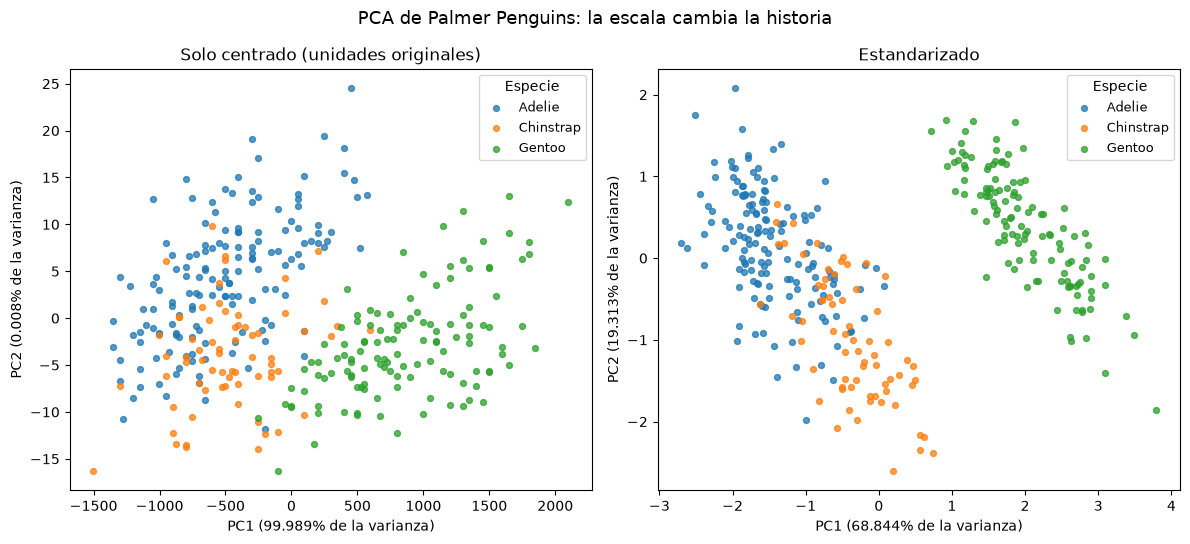

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
paneles = [("Solo centrado (unidades originales)", scores_raw, ratio_raw),
           ("Estandarizado", scores_std, ratio_std)]

for ax, (titulo, scores, ratio) in zip(axes, paneles, strict=True):
    for especie in np.unique(species):
        sel = species == especie
        ax.scatter(scores[sel, 0], scores[sel, 1], s=18, alpha=0.75, label=especie)
    ax.set(title=titulo,
           xlabel=f"PC1 ({ratio[0]:.3%} de la varianza)",
           ylabel=f"PC2 ({ratio[1]:.3%} de la varianza)")
    ax.legend(title="Especie", fontsize=9)

fig.suptitle("PCA de Palmer Penguins: la escala cambia la historia", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pca_penguins.png", dpi=150, bbox_inches="tight")
plt.show()

### Respuesta 6

¿Qué diferencias observan entre las dos representaciones? ¿Las especies quedan perfectamente separadas? Citen al menos un patrón visible y eviten afirmar que PCA es un clasificador.

**No, ninguna separa perfectamente:** Adelie y Chinstrap se mezclan en los dos paneles.

**Izquierdo (solo centrado).** PC1 recorre −1500 a 2100 en gramos —la masa disfrazada de componente— y PC2 vale el 0.008 % de la varianza, así que su dispersión vertical es ruido estirado. Gentoo se corre a la derecha (media 874 frente a −501 y −469), pero Adelie y Chinstrap forman una sola nube: se distinguen por el pico, no por el peso.

**Derecho (estandarizado).** Con los dos ejes aportando (68.84 % y 19.31 %) aparece estructura en ambas direcciones: Gentoo ocupa casi sola la zona PC1 > 0.72 (Adelie llega a 0.08; Chinstrap entra con 1 punto de 68) y Adelie y Chinstrap se ordenan por PC2 (medias 0.13 y −1.00), aunque sus rangos se solapan en la banda central.

PCA nunca vio `species`: el color se añadió después, así que los grupos indican señal taxonómica en las cuatro medidas, no que PCA clasifique.

## Tarea 6. Reconstruir y medir la pérdida

Reconstruyan los datos estandarizados con dos componentes:

\[
\widehat{Z}_2 = T_2 V_2^T.
\]

Luego vuelvan a las unidades originales y calculen:

- error relativo de Frobenius en el espacio estandarizado;
- RMSE por variable en sus unidades originales.

Verifiquen además que

\[
\frac{\lVert Z-\widehat{Z}_2\rVert_F}{\lVert Z\rVert_F}
= \sqrt{1-\text{varianza acumulada con 2 componentes}}.
\]

In [7]:
k = 2

Z_hat_2 = scores_std[:, :k] @ components_std[:k]
X_hat_2 = Z_hat_2 * scale + mean

relative_error_2 = np.linalg.norm(Z - Z_hat_2) / np.linalg.norm(Z)
theoretical_error_2 = np.sqrt(1 - ratio_std[:k].sum())

rmse = np.sqrt(((X - X_hat_2) ** 2).mean(axis=0))
rmse_by_feature = pd.DataFrame(
    {"rmse": rmse, "desv_est": scale, "rmse_relativo": rmse / scale},
    index=FEATURES,
)

print(f"Error relativo k={k}: {relative_error_2:.10f}")
print(f"Error teorico  k={k}: {theoretical_error_2:.10f}")
display(rmse_by_feature.round(4))

Error relativo k=2: 0.3441395510
Error teorico  k=2: 0.3441395510


,rmse,desv_est,rmse_relativo
bill_length_mm,2.1388,5.4596,0.3917
bill_depth_mm,0.5104,1.9748,0.2585
flipper_length_mm,4.1254,14.0617,0.2934
body_mass_g,326.7354,801.9545,0.4074


### Respuesta 7 — decisión final

El equipo debe comunicar los datos en un gráfico 2D, pero el análisis interno exige conservar al menos 90% de la varianza. ¿Qué preprocesamiento y cuántas componentes recomiendan para cada propósito? Justifiquen con la varianza acumulada, las cargas, el gráfico y el error de reconstrucción.

**Estandarizar en ambos casos.** Sin estandarizar, PC1 se lleva el 99.989 % con carga 0.9999 en `body_mass_g`: no es una componente, es la masa en gramos con otro nombre. Medir en kilogramos daría un resultado distinto, así que esa representación describe las unidades elegidas, no a los pingüinos.

**Para comunicar en 2D: estandarizado, 2 componentes.** Es lo máximo que admite un plano, y ahí sí vale la pena: acumulan **88.16 %** (68.84 % + 19.31 %) con los dos ejes en escala comparable. En el panel derecho de la figura se ve estructura en ambas direcciones —Gentoo ocupa PC1 > 0.72, y Adelie y Chinstrap se ordenan por PC2— mientras que en el panel izquierdo la nube se aplana en una franja horizontal porque PC2 aporta el 0.008 %. Además PC1 estandarizada es interpretable: cargas 0.58 (aleta), 0.55 (masa), 0.46 (pico largo) y −0.40 (pico profundo), es decir un eje de tamaño corporal contrastado con la forma del pico.

**Para el análisis interno: estandarizado, 3 componentes.** Dos no bastan —88.16 % queda por debajo del umbral—, así que **k90 = 3**, con 97.29 % acumulado.

**El costo de quedarse en dos** lo cuantifica la reconstrucción: error relativo de Frobenius **0.3441**, que coincide con √(1 − 0.8816) como exige la identidad. En unidades originales eso son 326.7 g de RMSE en la masa (41 % de su desviación), 4.13 mm en la aleta, 2.14 mm en el largo del pico y 0.51 mm en la profundidad. Aceptable para una figura de divulgación; excesivo si esos valores alimentan un cálculo posterior.

## Tarea 7. Verificación pública

La celda debe terminar sin errores. Estas comprobaciones no reemplazan las respuestas escritas.

In [8]:
assert df.shape == (344, 8)
assert clean.shape[0] == 342
assert X.shape == (342, 4)
assert np.isfinite(X).all()
assert np.allclose(Z.mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(Z.std(axis=0, ddof=1), 1.0, atol=1e-12)
assert np.allclose(components_std @ components_std.T, np.eye(4), atol=1e-10)
assert np.isclose(ratio_raw.sum(), 1.0)
assert np.isclose(ratio_std.sum(), 1.0)
assert np.cumsum(ratio_std)[k90 - 1] >= 0.90
assert k90 == 1 or np.cumsum(ratio_std)[k90 - 2] < 0.90
assert np.isclose(relative_error_2, theoretical_error_2, atol=1e-12)
assert (OUTPUT_DIR / "pca_penguins.png").exists()
print("VERIFICACIÓN PÚBLICA COMPLETA")

VERIFICACIÓN PÚBLICA COMPLETA
